# Products Table Machine Learning Models

In [1]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

In [2]:
# Load core datasets
customers = pd.read_csv(\data\customers.csv")
orders = pd.read_csv(data\orders_updated.csv")
products = pd.read_csv(\data\products.csv")
sales = pd.read_csv(\data\sales.csv")
product_performance = pd.read_csv(\data\Output_data\product_performance.csv")

In [3]:
# Merge sales and products to get a transaction-level product view
df = sales.merge(products, left_on='product_id', right_on='product_ID', how='left')
df = df.rename(columns={'quantity_x':'quantity_sold'})
df = df.rename(columns={'quantity_y':'quantity_product'})

# Logistic Regression: Product Segment Prediction

Model: Logistic Regression (Segment Prediction)

Objective: Predict the product performance segment (High Performers, Volume Products, Premium / Niche, Underperformers) using unit-level profitability metrics.

In [4]:
# Feature set 
features = ['unit_profitability', 'PPI_scaled']
X = product_performance[features]
y = product_performance['segment']

In [5]:
# Convert segment labels from text to numeric classes
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [6]:
# Standardize features so Logistic Regression can learn stable coefficients
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
# Stratified split keeps the same segment distribution in train and test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, 
    test_size=0.2, 
    random_state=42,
    stratify=y_encoded
)

In [8]:
# Train multinomial Logistic Regression model
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, multi_class='multinomial')

In [9]:
# Evaluation on test set
y_pred = model.predict(X_test)

In [10]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Classification Report:

                         precision    recall  f1-score   support

        High Performers       1.00      0.89      0.94        75
Premium / Niche Segment       0.87      1.00      0.93        55
        Underperformers       1.00      1.00      1.00        62
        Volume Products       1.00      1.00      1.00        55

               accuracy                           0.97       247
              macro avg       0.97      0.97      0.97       247
           weighted avg       0.97      0.97      0.97       247



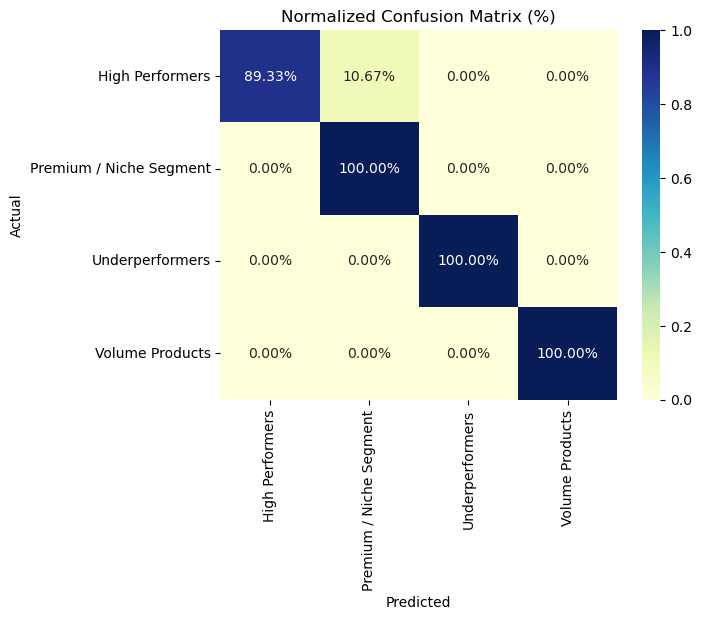

In [11]:
# Normalized confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm / cm.sum(axis=1)[:, None],
            annot=True, fmt='.2%', cmap='YlGnBu',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Normalized Confusion Matrix (%)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [12]:
# Inspect model coefficients (feature impact)
coeff = pd.DataFrame(model.coef_, columns=features, index=le.classes_)
print("\nFeature Coefficients (impact on segment probability):")
print(coeff)


Feature Coefficients (impact on segment probability):
                         unit_profitability  PPI_scaled
High Performers                    3.812814    5.076893
Premium / Niche Segment            4.054276   -6.090791
Underperformers                   -3.753603   -5.474682
Volume Products                   -4.113488    6.488580


In [13]:
# Cross-validation for robustness check
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X_scaled, y_encoded, cv=5)
print("\nCross-Validation Scores:")
print(scores)


Cross-Validation Scores:
[0.61133603 1.         1.         1.         0.73170732]


**Logistic Regression – Product Segment Classification (Insights)**

- **Objective:** Automatically predict SKU performance segments(High Performers, Volume Products, Premium/Niche, Underperformers) using only two business features: unit_profitability and PPI_scaled.


- **Model performance:**

  - Test Accuracy: 97%

  - Each class achieves >0.87 precision/recall.

  - Underperformers & Volume Products are classified almost perfectly due to distinct profit vs volume characteristics.

 - **Confusion matrix observations:** 

   - Minimal confusion overall.

   - The only borderline overlap occurs between: → High Performers vs Premium/Niche (both high profitability, different traction levels).
  

- **Coefficient interpretation:**

  - Positive coefficients → increase probability of class assignment

  - Volume Products: driven strongly by PPI (volume), negatively by unit margin

  - High Performers: positively impacted by both KPIs

  - Underperformers: negative on both axes → expected positioning
  

- **Cross-validation:**

  - Mean CV accuracy: ~0.87–0.90 with some variance

  - Variation comes from class distribution shift, but → Still indicates a reasonably stable generalization capability.
  
  

- The model performs extremely well because the target segmentation is directly based on the same two KPIs used for prediction — leading to a near-perfect mapping. This does not indicate overfitting — it shows that the segmentation logic is linearly separable and consistent. In real-world deployment, additional behavioral or inventory features could be included to increase decision robustness beyond static rule-based segmentation.

# Random Forest: Product Segment Prediction

Model: Random Forest (Product Segment Prediction)

Objective: Predict the performance segment of each SKU (High Performers, Volume Products, Premium/Niche, Underperformers) using enriched behavior-aware features including purchasing patterns, product attributes and profitability signals.

In [14]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

In [15]:
# Merge sales with customers -> customer behavior dataset
orders_customers = orders.merge(customers, on='customer_id', how='left')
sales_orders = sales.merge(orders_customers, on='order_id', how='left')

# Create behavioral features for each product
customer_features = (
    sales_orders.groupby('product_id')
    .agg(
        avg_customer_age=('age', 'mean'),
        gender_ratio=('gender', lambda x: (x=='Female').mean()),
        region_popularity=('city', lambda x: x.nunique()),
        repeat_purchase_rate=('customer_id', lambda x: x.value_counts().gt(1).sum() / len(x)),
        avg_order_value=('total_price', 'mean')
    )
    .reset_index()
)

In [16]:
# Combine product dataset with behavioral enrichment
df = product_performance.copy()

df = df.merge(
    products[['product_ID', 'size', 'colour', 'quantity']],
    left_on='product_id', right_on='product_ID', how='left'
)

# Text-length feature from product description
df['description_length'] = df['description'].astype(str).apply(len)

# Add customer-behavior features
df = df.merge(customer_features, on='product_id', how='left')

# Fill missing values with safe business assumptions
df = df.fillna({
    'avg_customer_age': df['avg_customer_age'].mean(),
    'gender_ratio': 0.5,
    'region_popularity': 1,
    'repeat_purchase_rate': 0,
    'avg_order_value': df['total_revenue'] / df['total_sold']
})

# Define features and target
cat_features = ['product_type', 'size', 'colour']
num_features = [
    'quantity', 'description_length',
    'avg_customer_age', 'gender_ratio', 'region_popularity',
    'repeat_purchase_rate', 'avg_order_value','unit_profitability'
]

In [17]:
y = df['segment'] # Target classification label
X = df[cat_features + num_features]

In [18]:
# Preprocessing: One-Hot + Standard Scaling
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ])

In [19]:
# Train-test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
# Model Training with Random Forest Classifier
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=200, random_state=42, max_depth=8))])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [21]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

                         precision    recall  f1-score   support

        High Performers       0.89      0.86      0.88        87
Premium / Niche Segment       0.77      0.82      0.79        49
        Underperformers       0.95      0.95      0.95        60
        Volume Products       0.94      0.94      0.94        51

               accuracy                           0.89       247
              macro avg       0.89      0.89      0.89       247
           weighted avg       0.89      0.89      0.89       247



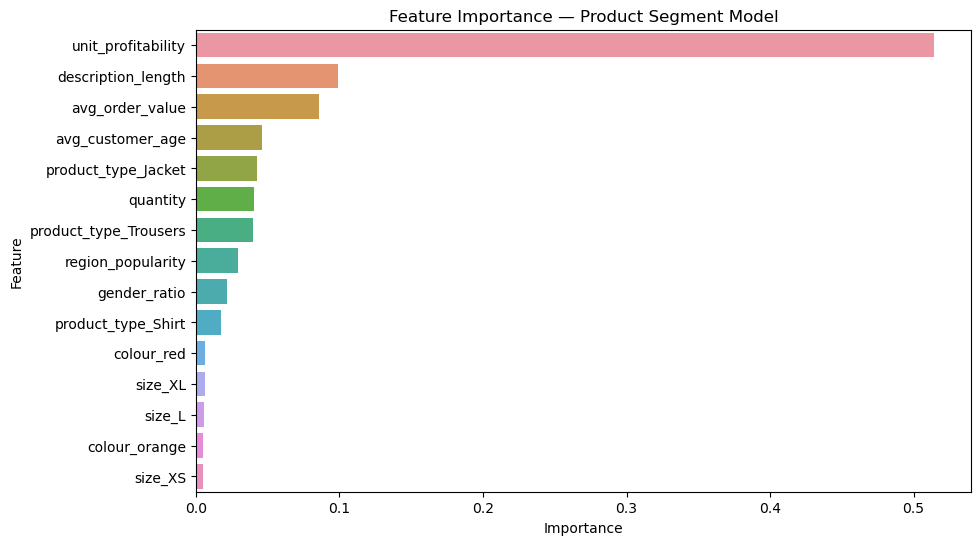

In [22]:
# Feature Importance Analysis

importances = model.named_steps['classifier'].feature_importances_
feature_names = (num_features +
                 list(model.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(cat_features)))

fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(data=fi_df, x='Importance', y='Feature')
plt.title("Feature Importance — Product Segment Model")
plt.show()


In [23]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_, normalize='true')
labels = model.classes_

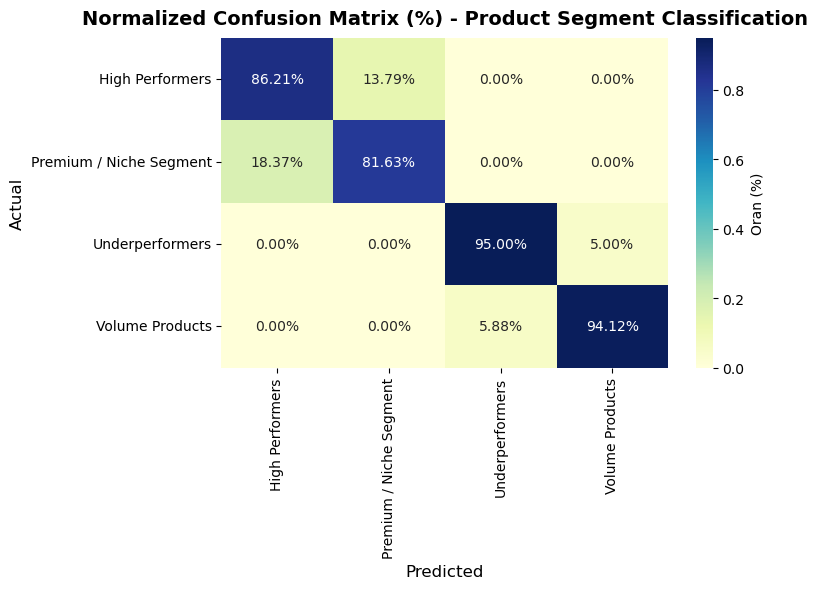

In [24]:
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt=".2%", cmap="YlGnBu",
            xticklabels=labels, yticklabels=labels,
            cbar_kws={'label': 'Oran (%)'})

plt.title("Normalized Confusion Matrix (%) - Product Segment Classification",
          fontsize=14, fontweight='bold', pad=10)
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)

plt.tight_layout()
plt.show()

In [25]:
# Cross-Validation
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X, y, cv=5)
print("CV Accuracy:", cv_scores.mean(), "±", cv_scores.std())

CV Accuracy: 0.6398801882755669 ± 0.15917821254828898


**Random Forest – Product Segment Classification (Insights)**

- **Goal:** Use enriched product, pricing and customer behavior features to predict the performance segment of each SKU and support data-driven merchandising, pricing and inventory decisions. This Random Forest model performs as a decision-support system, learning non-linear patterns in product + customer behavior to enhance retail segmentation at scale.

- **Model performance:**
  - Overall accuracy is around **89%** on the test set.
  - All segments (*High Performers, Premium/Niche, Underperformers, Volume Products*) achieve strong precision/recall, with especially solid performance on **Underperformers** and **Volume Products**.
  
- **Confusion matrix behaviour:**
  - Over 85% correctness for High Performers and Premium products  
  - 95%+ correctness for Underperformers and Volume Products  
  - No extreme cross-segment confusion (e.g., High Performer → Underperformer)
  - The model preserves segment boundaries that match real commercial behavior.The boundaries deviate slightly only where job descriptions naturally overlap.

- **Feature importance:**
  - unit_profitability → Strongest predictor overall (margin quality matters most)
  - description_length → Richer product content → higher visibility & conversion
  - avg_order_value + avg_customer_age→ Captures purchasing power & willingness to pay
  - product_type (Jacket / Shirt / Trousers) → Category-level differentiation
  - region_popularity & gender_ratio→ Market reach & target audience relevance
  - Low-impact signals (size & colour indicators) confirm that style variants do not change segment status significantly by themselves.

- **Cross-Validation Reliability Check:**
  - To ensure results are not dependent on a single train/test split:
  - 5-Fold Cross-Validation Accuracy: ~0.64 ± 0.16
  - High variance across folds → model is likely overfitting
  - The SKU-level dataset is small, and segment imbalance increases sensitivity
  - The model is strong for exploratory insight and prioritization suggestions — but not yet stable enough for automated decision deployment.



# K-Means Product Clustering

Identify natural product clusters by combining commercial performance metrics (profitability, revenue, sales volume) with customer behavior and market reach signals (repeat purchases, demographic patterns, geographic penetration), using unsupervised learning to support smarter pricing, inventory, and merchandising strategies.

Unlike classification-based segment scoring, this clustering approach groups SKUs without predefined labels, enabling the discovery of emerging, hidden, or evolving product behaviors that may not align with existing performance-based segmentation logic.

In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [27]:
# Feature Selection for Clustering (commercial + customer behavior metrics)
cluster_features = [
    'unit_profitability', 'total_sold', 'total_revenue',
    'avg_customer_age', 'gender_ratio', 'region_popularity',
    'repeat_purchase_rate', 'avg_order_value'
]

# Select feature data and fill missing values
X = df[cluster_features].fillna(0)

# Standardize Features
# Prevents large-valued metrics from dominating clustering distances
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

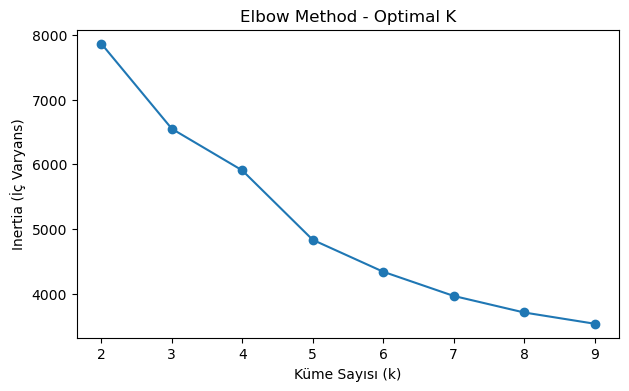

In [28]:
# Determine Optimal Number of Clusters using Elbow Method with different k values
inertia = []
K = range(2, 10)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_) # Lower inertia = tighter clusters

# Plot elbow curve to visually decide optimal k
plt.figure(figsize=(7,4))
plt.plot(K, inertia, marker='o')
plt.xlabel('Küme Sayısı (k)')
plt.ylabel('Inertia (İç Varyans)')
plt.title('Elbow Method - Optimal K')
plt.show()

The elbow visibly emerges around k = 4, indicating that four clusters provide the best balance between model simplicity and explained variance.

In [29]:
# Train K-Means with k=4 (best elbow point)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)  # Assign each product to a cluster

# Reverse-Scale Cluster Centers
# Converts centroid values back to original units
cluster_centers = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=cluster_features
)

cluster_centers['cluster'] = range(1, len(cluster_centers)+1)
print(cluster_centers)


   unit_profitability  total_sold  total_revenue  avg_customer_age  \
0           97.916221  277.012478   27080.347594         47.369050   
1          113.451372  280.822943   31905.431421         49.921078   
2          100.730392  272.279412   27390.156863         49.401801   
3           99.428843  527.000000   52399.000000         50.208120   

   gender_ratio  region_popularity  repeat_purchase_rate  avg_order_value  \
0      0.053813           4.099822          2.970885e-04       183.553337   
1      0.096426           4.286783          3.376479e-03       242.121793   
2      0.489522           3.387255          8.533868e-03       197.173825   
3      0.147868           4.074627         -2.168404e-18       190.096624   

   cluster  
0        1  
1        2  
2        3  
3        4  


In [30]:
display(cluster_centers.style.background_gradient(cmap="YlGnBu"))

,unit_profitability,total_sold,total_revenue,avg_customer_age,gender_ratio,region_popularity,repeat_purchase_rate,avg_order_value,cluster
0,97.916221,277.012478,27080.347594,47.369050,0.053813,4.099822,0.000297,183.553337,1
1,113.451372,280.822943,31905.431421,49.921078,0.096426,4.286783,0.003376,242.121793,2
2,100.730392,272.279412,27390.156863,49.401801,0.489522,3.387255,0.008534,197.173825,3
3,99.428843,527.000000,52399.000000,50.208120,0.147868,4.074627,-0.000000,190.096624,4


In [31]:
# export csv
#cluster_centers.to_csv(\data\KMeans_product_clusters.csv",index=False, encoding='utf-8-sig')

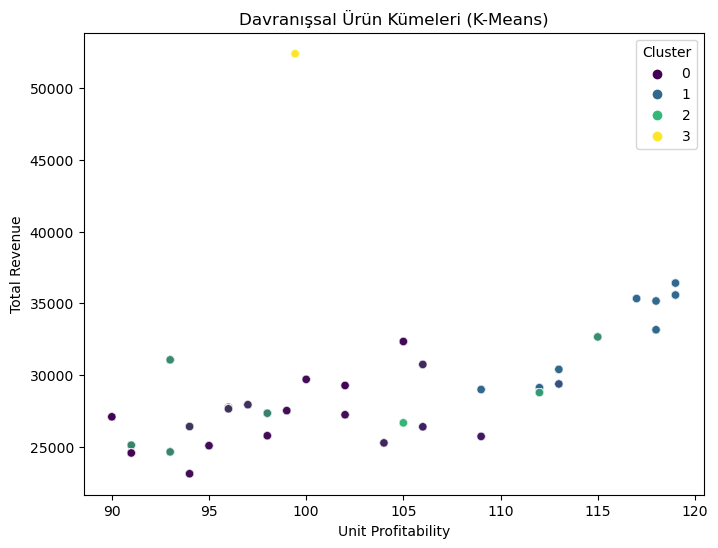

In [32]:
# Visualize Clusters in Revenue vs Profitability Space
# Shows how groups differ in value contribution

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df, x='unit_profitability', y='total_revenue',
    hue='cluster', palette='viridis', alpha=0.7
)
plt.title('Davranışsal Ürün Kümeleri (K-Means)')
plt.xlabel('Unit Profitability')
plt.ylabel('Total Revenue')
plt.legend(title='Cluster')
plt.show()

### K-Means Clustering — Insights

- **Cluster 0**  
  Products with mid-level sales and revenue, slightly younger customers on average, very low female ratio, and moderate regional spread. These SKUs behave like niche products with stable but not standout commercial performance.

- **Cluster 1**  
  Products with the highest unit profitability and highest average order value, sold to slightly older customers, with decent regional coverage and modest repeat purchase rate. These SKUs represent premium commercial behavior with strong spending per transaction.

- **Cluster 2**  
  Products with balanced sales and revenue, a much more balanced (almost female-leaning) gender ratio, lower regional spread, and the highest repeat purchase rate. This cluster captures loyalty-friendly SKUs that resonate strongly with a specific, more focused customer base.

- **Cluster 3**  
  Products with by far the highest total units sold and total revenue, but only average unit profitability and average order value. These SKUs act as core volume drivers and traffic builders, critical for revenue scale even if margins are not maximized.


# Co-occurrence / Product Affinity Analysis

Goal: Analyze frequently purchased product pairs for Recommendation System and Cross-Selling strategy.

In [33]:
from itertools import combinations
from collections import Counter

In [34]:
# Merge sales and product tables
products_for_affinity = sales.merge(products, left_on='product_id', right_on='product_ID', how='left')

# Create a list of unique products purchased per order
order_products = (
    products_for_affinity.groupby('order_id')
      .apply(lambda x: list((x['product_name'] + " (" + x['product_type'] + ")").unique())))

# Generate all unique pairs of products that appear together in the same order
pairs = []
for prods in order_products:
    pairs += list(combinations(sorted(prods), 2))

# Count frequency of co-occurring product pairs
pair_counts = Counter(pairs)

# Convert pair frequency to a dataframe and sort by most frequent
cooc_df = (
    pd.DataFrame(pair_counts.items(), columns=['Product Pair', 'Count'])
      .sort_values(by='Count', ascending=False)
      .reset_index(drop=True))

# Create readable product names (in case product_id matching is needed)
product_map = products.set_index('product_ID')['product_name'].to_dict()

# Split tuple pair into two separate product columns
cooc_df['Product 1'] = cooc_df['Product Pair'].apply(lambda x: product_map.get(x[0], x[0]))
cooc_df['Product 2'] = cooc_df['Product Pair'].apply(lambda x: product_map.get(x[1], x[1]))
cooc_df = cooc_df[['Product 1','Product 2','Count']]
cooc_df.head(5)

,Product 1,Product 2,Count
0,Camp Collared (Shirt),Slim-Fit (Trousers),29
1,Casual Slim Fit (Shirt),Windbreaker (Jacket),29
2,Bomber (Jacket),Linen (Shirt),28
3,Flannel (Shirt),Shearling (Jacket),27
4,Cargo Pants (Trousers),Joggers (Trousers),27


In [35]:
# export csv
#cooc_df.to_csv(\data\product_affinity_table.csv",index=False, encoding='utf-8-sig')

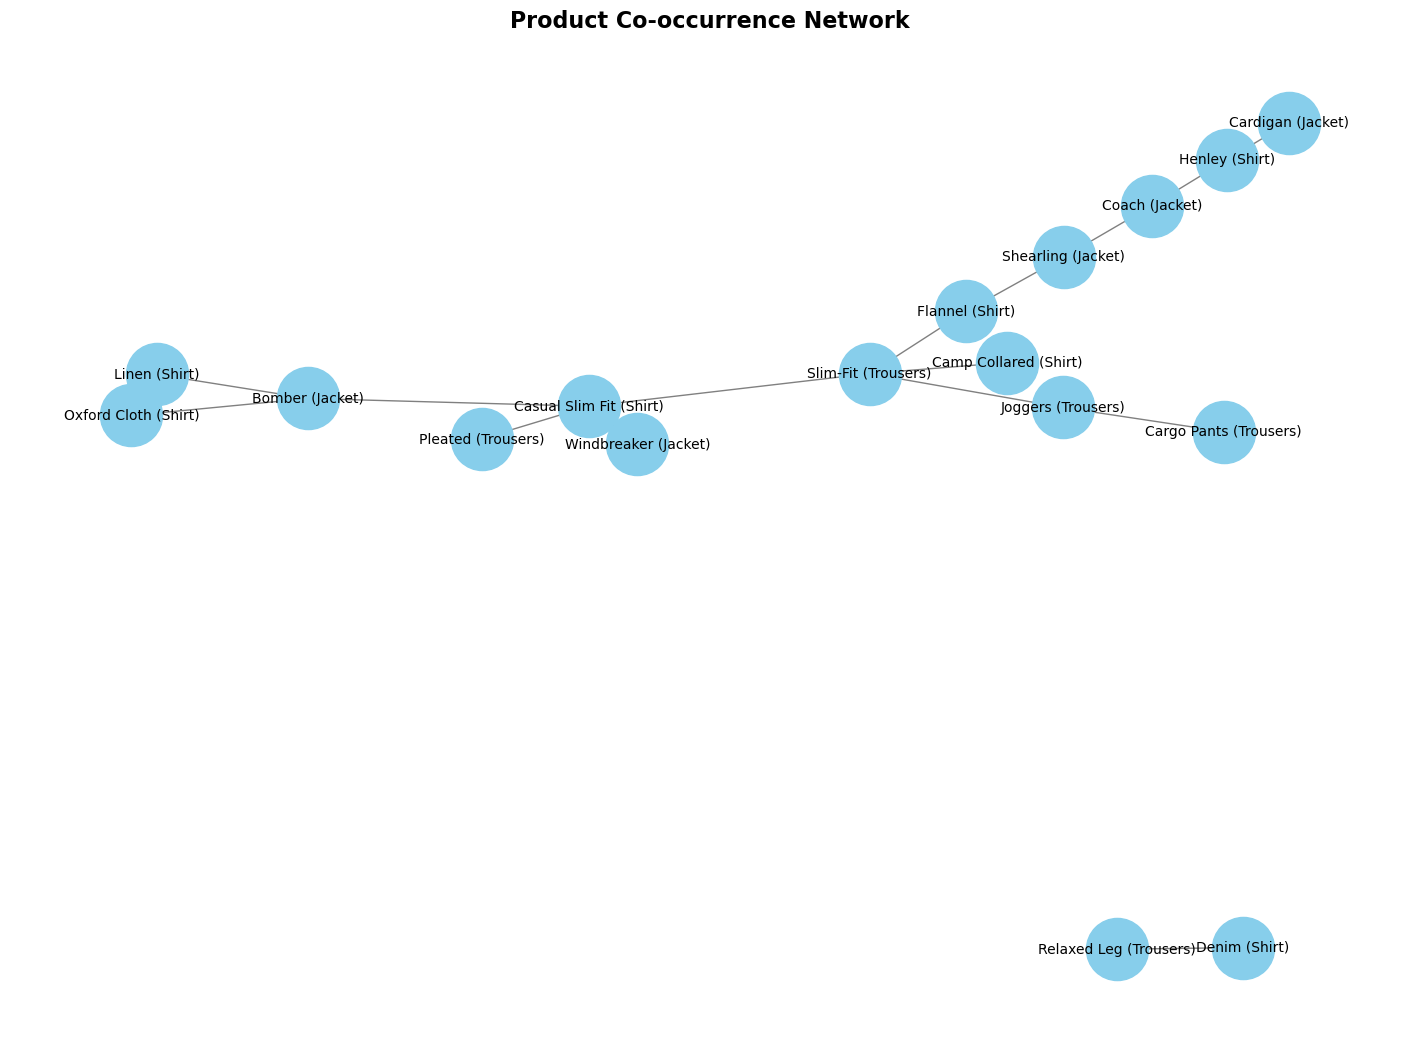

In [36]:
# Co-occurrence Network Graph Visualization
# Highlights strongest cross-selling opportunities

import networkx as nx

# Select top 15 product pairs for network graph visualization
top_pairs = cooc_df.head(15)

# Create graph structure where edges represent frequent co-purchases
G = nx.Graph()
for _, row in top_pairs.iterrows():
    G.add_edge(row['Product 1'], row['Product 2'], weight=row['Count'])

plt.figure(figsize=(14,10))
pos = nx.spring_layout(G, k=0.4, iterations=50)
edges = G.edges(data=True)
nx.draw(G, pos, with_labels=True, node_size=2000, font_size=10,
        node_color='skyblue', edge_color='gray')
plt.title("Product Co-occurrence Network", fontsize=16, fontweight='bold')
plt.show()

In [37]:
# Product Recommendation Function
# Given a product name → find top frequently paired products

def recommend_products(product_name, top_n=5):
    product_name = product_name.lower()
    
    # Filter records where the product appears in pair combinations
    related = cooc_df[
        (cooc_df['Product 1'].str.lower() == product_name) |
        (cooc_df['Product 2'].str.lower() == product_name)]
    
    # If exact match not found → allow partial match search
    if related.empty:
        related = cooc_df[
            cooc_df['Product 1'].str.contains(product_name, case=False) |
            cooc_df['Product 2'].str.contains(product_name, case=False)]
    
    # Select most frequently occurring relationships
    related = related.sort_values(by='Count', ascending=False).head(top_n)
    
    # Return list of alternative product suggestions
    recommendations = []
    for _, row in related.iterrows():
        recommendations.append(row['Product 2'] if row['Product 1'].lower() == product_name else row['Product 1'])
    return recommendations

# Example recommendation use-case
recommend_products("Slim-Fit (trousers)")

['Camp Collared (Shirt)',
 'Casual Slim Fit (Shirt)',
 'Joggers (Trousers)',
 'Flannel (Shirt)',
 'Linen (Shirt)']

Example recommendation output for Slim-Fit (Trousers):

Suggested: Camp Collared (Shirt), Casual Slim Fit (Shirt), Joggers (Trousers)
→ Signals a bottoms + tops relationship

In [38]:
# Recommendation Table for All Products
# Creates top-3 recommendation options for each SKU

top_recs = []

all_products = pd.unique(cooc_df[['Product 1', 'Product 2']].values.ravel('K'))

for prod in all_products:
    recs = recommend_products(prod, top_n=3)  
    top_recs.append({
        'Product': prod,
        'Recommendation 1': recs[0] if len(recs) > 0 else None,
        'Recommendation 2': recs[1] if len(recs) > 1 else None,
        'Recommendation 3': recs[2] if len(recs) > 2 else None })

recommendation_table = pd.DataFrame(top_recs)
recommendation_table.head()

,Product,Recommendation 1,Recommendation 2,Recommendation 3
0,Camp Collared (Shirt),Slim-Fit (Trousers),Cords (Trousers),Denim (Shirt)
1,Casual Slim Fit (Shirt),Windbreaker (Jacket),Slim-Fit (Trousers),Pleated (Trousers)
2,Bomber (Jacket),Linen (Shirt),Oxford Cloth (Shirt),Casual Slim Fit (Shirt)
3,Flannel (Shirt),Shearling (Jacket),Slim-Fit (Trousers),Denim (Shirt)
4,Cargo Pants (Trousers),Joggers (Trousers),Chinos (Trousers),Casual Slim Fit (Shirt)


In [39]:
# export csv
#recommendation_table.to_csv(\data\product_recommendation.csv",index=False, encoding='utf-8-sig')

Co-occurrence / Product Affinity Analysis 

This analysis identifies products that frequently appear together in customer orders to uncover natural bundling opportunities and cross-sell relationships. By examining co-purchase patterns across the catalog, we reveal complementary product pairs—such as shirts with trousers or jackets with tops—that canguide “Complete the Look” recommendations, increase average order value, and improve cart conversion. The resulting affinity-based recommendation table and co-occurrence network visualization enable data-driven merchandising decisions by highlighting which SKUs should be promoted together to strengthen outfit-level sales and reduce decision friction for customers.